In [17]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools

import re
import os
import pickle
from cpymad.madx import Madx

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')



import elements as el
import optimisers as op
import importlib

# Creating the knobs

In [121]:
importlib.reload(op)

# Creating the orthogonal knobs in LSS4
line = el.initialise_lineQ22();
opt_x_LSS4 = op.set_x_knobLSS4(line)

Loading line from dict: 100%|██████████| 4598/4598 [00:00<00:00, 23093.81it/s]


Done loading line from dict.           


Slicing line: 100%|██████████| 4603/4603 [00:00<00:00, 243983.08it/s]


Non-channeled particle lost at element ap.up.mst21774_aper (index 1117) on turn 0
Adjusting ap.up.mst21774_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21774_aper (index 1122) on turn 0
Adjusting ap.do.mst21774_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21779_aper (index 1125) on turn 0
Adjusting ap.up.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21779_aper (index 1130) on turn 0
Adjusting ap.do.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21794_aper (index 1133) on turn 0
Adjusting ap.up.mst21794_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21794_a

<Axes: >

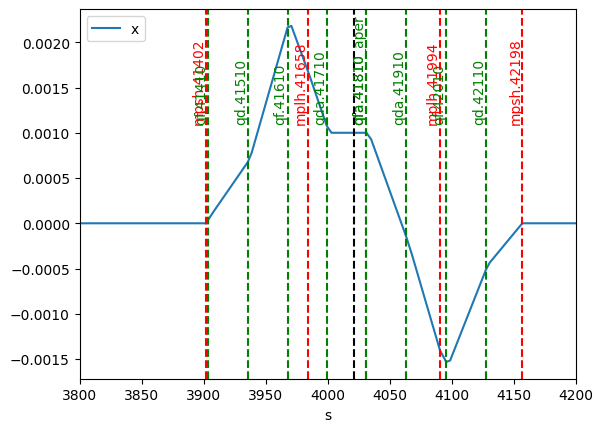

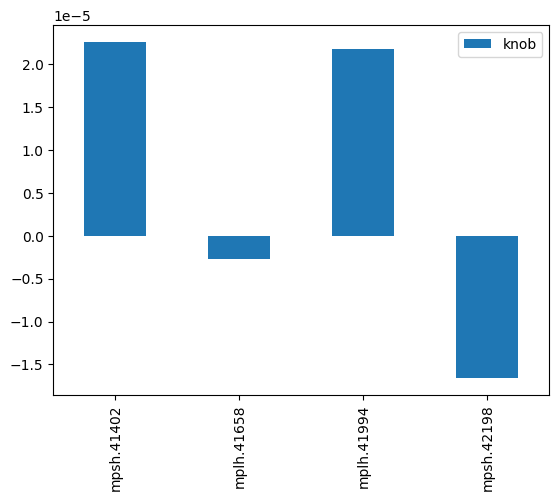

In [122]:
bumpers = {
    "mpsh.41402": "kmpsh41402",
    "mplh.41658": "kmplh41658",
    "mplh.41994": "kmplh41994",
    "mpsh.42198": "kmpsh42198"
}

def plot_bump(ax, show_elements=True, **kwargs):
    tw = line.twiss(continue_on_closed_orbit_error=True, method ="4d").to_pandas()
    tw.index = tw.name
    tw.plot(x='s', y='x', ax=ax, **kwargs)
    if show_elements:
        ax.axvline(tw.loc['TECA.entry'].s, color='k', linestyle='--')
        for name in ['mpsh.41402', 'mplh.41658', 'mplh.41994', 'mpsh.42198']:
            ax.axvline(tw.loc[name].s, color='r', linestyle='--', label=name)
            ax.text(tw.loc[name].s, tw.x.max()/2, name, rotation=90, verticalalignment='bottom', horizontalalignment='right', color='red')

        for name in tw.loc['mpsh.41402':'mpsh.42198'].name:
            if 'q' in name:
                ax.axvline(tw.loc[name].s, color='g', linestyle='--', label=name)
                ax.text(tw.loc[name].s, tw.x.max()/2, name, rotation=90, verticalalignment='bottom', horizontalalignment='right', color='green')

    ax.set_xlim(3800, 4200)

fig, ax = plt.subplots()

plot_bump(ax)

settings = {}
for name, knob in bumpers.items():
    settings[name] = line.vv[knob]

settings = pd.DataFrame(settings, index=['knob']).T
settings.plot(kind='bar')

In [123]:
from copy import copy
line.env["x_teca_knob"] =  0 # mm
for name, knob in bumpers.items():
    line.env[name + "_init_x"] = copy(line.vv[knob])
    line.vv[knob] = name + "_init_x * x_teca_knob"

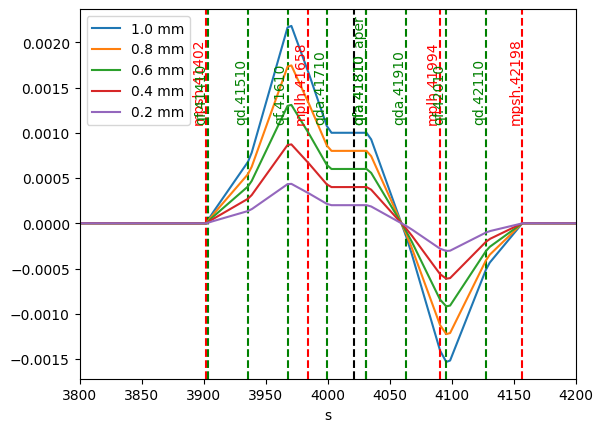

In [124]:
fig, ax = plt.subplots()
for i, knob in enumerate([0.2, 0.4, 0.6, 0.8, 1.0][::-1]):
    line.env["x_teca_knob"] = knob
    plot_bump(ax, show_elements=True if i == 0 else False, label=f"{knob:.1f} mm")

                                             
Optimize - start penalty: 0.0001                            
Matching: model call n. 13 penalty = 9.3538e-13              
Optimize - end penalty:  9.35381e-13                            


<Axes: >

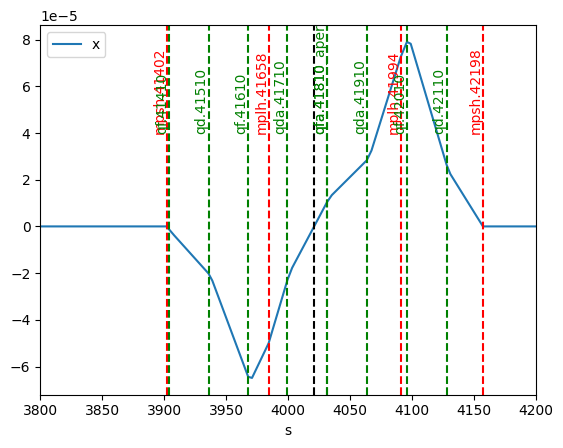

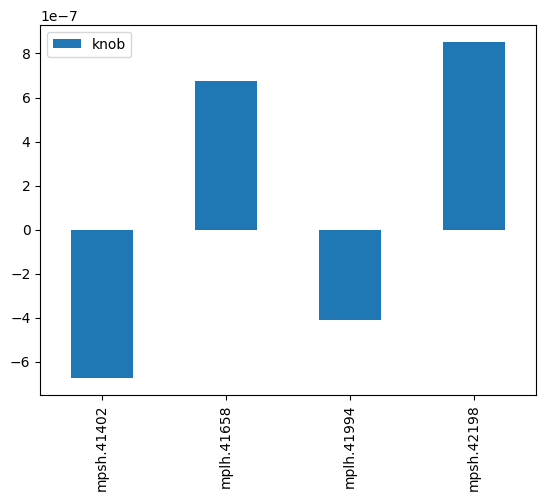

In [125]:
line.env["x_teca_knob"] =  0
opt_x_LSS4 = op.set_px_knobLSS4(line)

fig, ax = plt.subplots()
plot_bump(ax, show_elements=True)

settings = {}
for name, knob in bumpers.items():
    settings[name] = line.vv[knob]

settings = pd.DataFrame(settings, index=['knob']).T
settings.plot(kind='bar')

In [126]:
line.env["px_teca_knob"] =  0 # mm
for name, knob in bumpers.items():
    line.env[name + "_init_px"] = copy(line.vv[knob])
    line.vv[knob] = name + "_init_x * x_teca_knob + " + name + "_init_px * px_teca_knob "

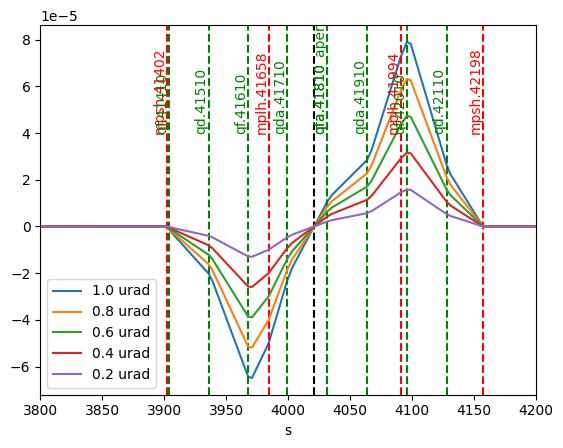

In [127]:
fig, ax = plt.subplots()
for i, knob in enumerate([0.2, 0.4, 0.6, 0.8, 1.0][::-1]):
    line.env["px_teca_knob"] = knob
    plot_bump(ax, show_elements=True if i == 0 else False, label=f"{knob:.1f} urad")

In [128]:
x_knob_range = np.linspace(-1, 1, 10)
px_knob_range = np.linspace(-1, 1, 10)

results = {}

for i, x_knob in enumerate(x_knob_range):
    for j, px_knob in enumerate(px_knob_range):
        print(i, j, end='\r')
        line.env["x_teca_knob"] = x_knob
        line.env["px_teca_knob"] = px_knob
        tw = line.twiss(continue_on_closed_orbit_error=True, method ="4d").to_pandas()
        tw.index = tw.name
        results[i*len(px_knob_range) + j] = {
            "x_mm": tw.loc['TECA.entry'].x * 1e3,  # Convert to mm
            "px_um": tw.loc['TECA.entry'].px * 1e6,  # Convert to um
            "x_knob": x_knob,
            "px_knob": px_knob
        }

results_df = pd.DataFrame.from_dict(results, orient='index')

<Axes: xlabel='x_knob', ylabel='px_knob'>

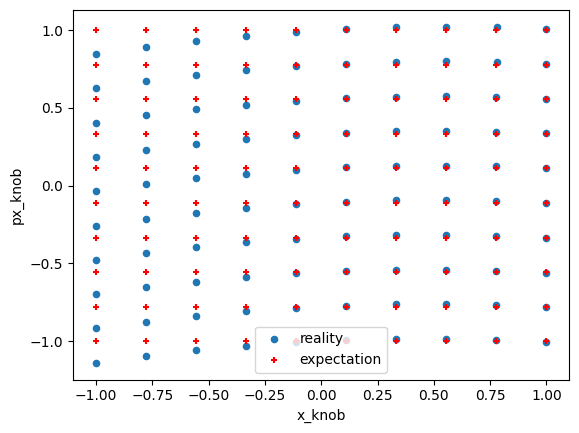

In [132]:
fig, ax = plt.subplots()
results_df.plot.scatter(x='x_mm', y='px_um', marker='o', ax=ax, label='reality')
results_df.plot.scatter(x='x_knob', y='px_knob', marker='+', ax=ax, color='red', label='expectation')